In [11]:
# 0. IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, ConfusionMatrixDisplay
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [13]:
# 1. DATA LOADING & STRUCTURE
# ─────────────────────────────────────────────
print("=" * 60)
print("  STEP 1: DATA LOADING & STRUCTURE EXPLORATION")
print("=" * 60)

GESTURE_MAP = {0: "Rock", 1: "Scissors", 2: "Paper", 3: "OK"}
FILE_PATHS = [
    "0.csv",   # Rock    — place all 4 CSVs in the same folder as this script
    "1.csv",   # Scissors
    "2.csv",   # Paper
    "3.csv",   # OK
]
# ── If your files are in a different folder, change the paths above, e.g.:
#    "C:/Users/you/data/0.csv"  or  "/home/you/data/0.csv"

dfs = []
for path in FILE_PATHS:
    df = pd.read_csv(path, header=0)
    # Last column is the label; rename it uniformly
    df.columns = [f"ch_{i}" for i in range(df.shape[1] - 1)] + ["label"]
    # Force label to the known gesture class
    df["label"] = int(path.split(".")[0])
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

print(f"\nDataset shape      : {data.shape}")
print(f"Features           : {data.shape[1] - 1}  (64 sEMG channels)")
print(f"Total samples      : {data.shape[0]}")
print(f"\nClass distribution :")
for cls, name in GESTURE_MAP.items():
    n = (data["label"] == cls).sum()
    print(f"  {name:10s} ({cls})  →  {n:5d} samples")

print(f"\nMissing values     : {data.isnull().sum().sum()}")
print(f"\nFirst 3 rows:\n{data.head(3)}")
print(f"\nBasic stats (first 8 channels):\n{data.iloc[:, :8].describe().round(2)}")

  STEP 1: DATA LOADING & STRUCTURE EXPLORATION

Dataset shape      : (11674, 65)
Features           : 64  (64 sEMG channels)
Total samples      : 11674

Class distribution :
  Rock       (0)  →   2909 samples
  Scissors   (1)  →   2902 samples
  Paper      (2)  →   2942 samples
  OK         (3)  →   2921 samples

Missing values     : 0

First 3 rows:
   ch_0  ch_1  ch_2  ch_3  ch_4  ch_5   ch_6  ch_7  ch_8  ch_9  ...  ch_55  \
0 -47.0  -6.0  -5.0  -7.0  13.0  -1.0   35.0 -10.0  10.0  -4.0  ...  -25.0   
1 -19.0  -8.0  -8.0  -8.0 -21.0  -6.0  -79.0  12.0   0.0   5.0  ...  -83.0   
2   2.0   3.0   0.0   2.0   0.0  22.0  106.0 -14.0 -16.0  -2.0  ...  -38.0   

   ch_56  ch_57  ch_58  ch_59  ch_60  ch_61  ch_62  ch_63  label  
0   47.0    6.0    6.0    5.0   13.0   21.0  111.0   15.0      0  
1    7.0    7.0    1.0   -8.0    7.0   21.0  114.0   48.0      0  
2  -11.0    4.0    7.0   11.0   33.0   39.0  119.0   43.0      0  

[3 rows x 65 columns]

Basic stats (first 8 channels):
          


  STEP 2: PREPROCESSING & EDA


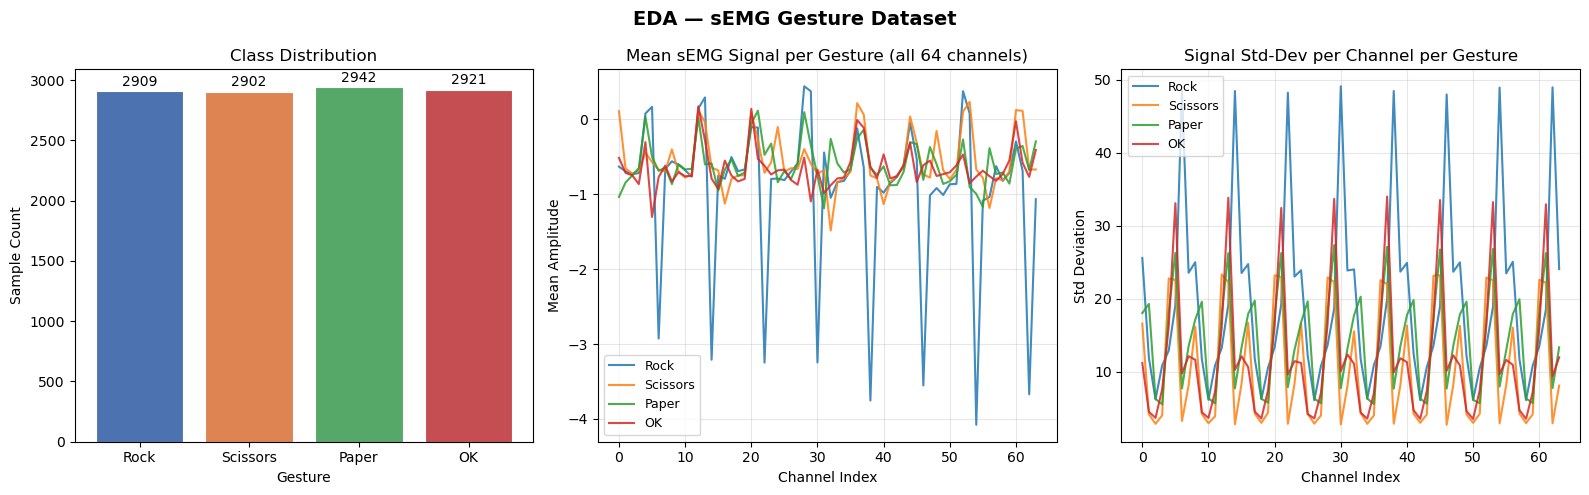

  [Saved] eda_overview.png


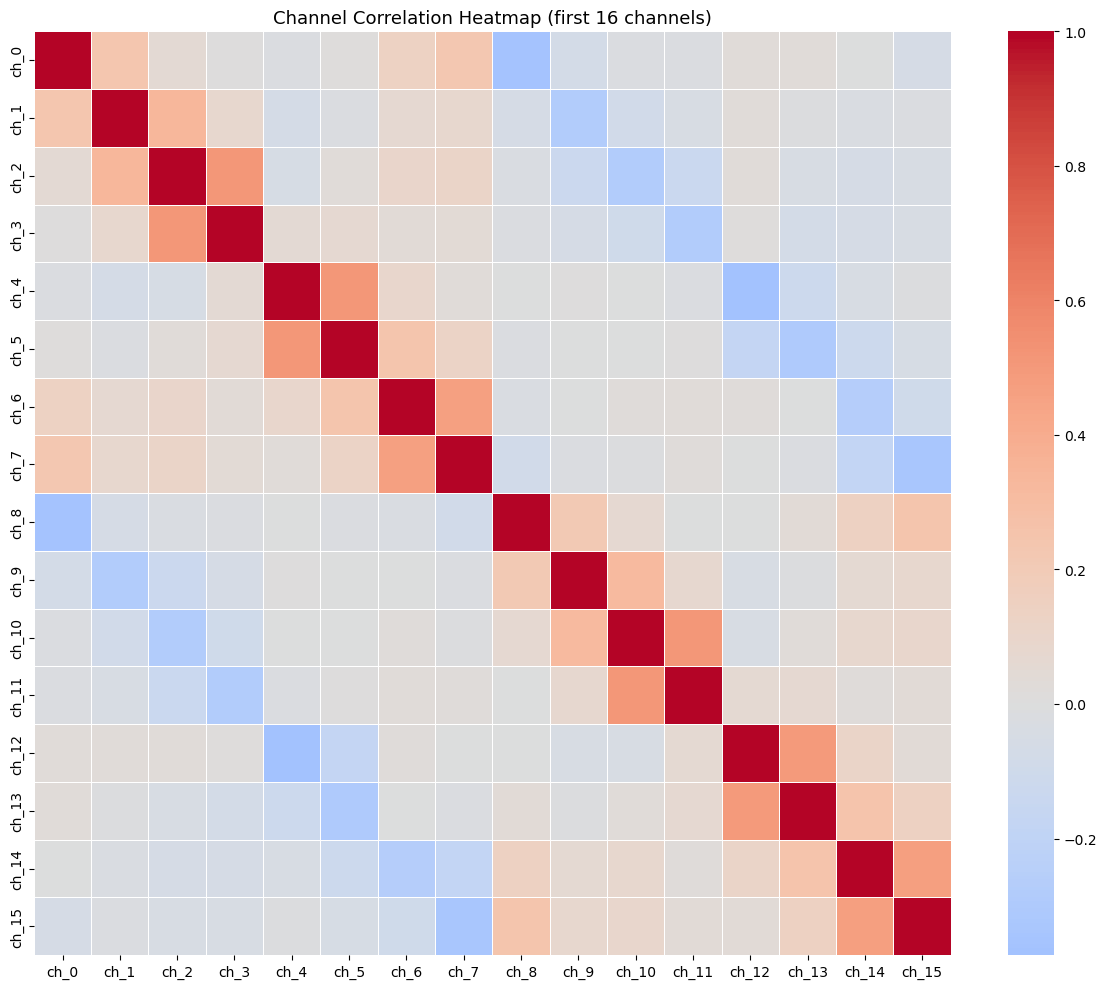

  [Saved] eda_correlation.png


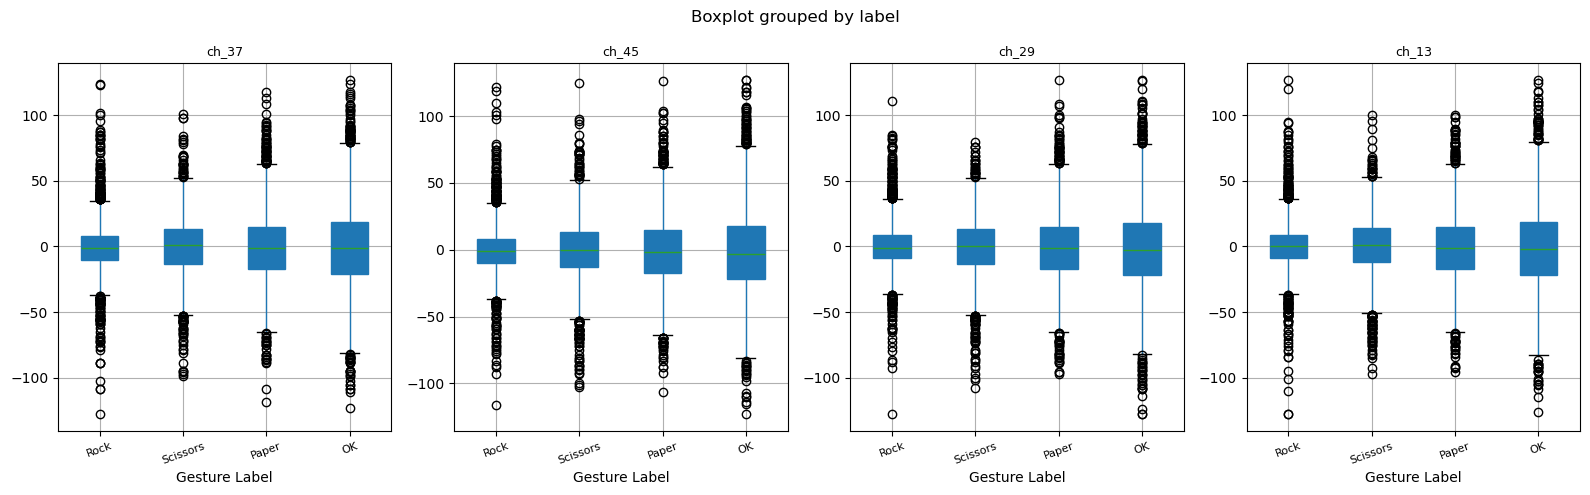

  [Saved] eda_boxplots.png

  Preprocessing: StandardScaler applied.
  Train/Test split: 80% / 20% (stratified, random_state=42)


In [19]:
# 2. EDA PLOTS
print("\n" + "=" * 60)
print("  STEP 2: PREPROCESSING & EDA")
print("=" * 60)

feature_cols = [c for c in data.columns if c.startswith("ch_")]
X = data[feature_cols].values
y = data["label"].values

# ── Figure 1: Class distribution ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("EDA — sEMG Gesture Dataset", fontsize=14, fontweight="bold")

counts = data["label"].value_counts().sort_index()
axes[0].bar(
    [GESTURE_MAP[i] for i in counts.index],
    counts.values,
    color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"],
    edgecolor="white", linewidth=0.8
)
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Sample Count")
axes[0].set_xlabel("Gesture")
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 str(val), ha="center", va="bottom", fontsize=10)

# ── Figure 2: Mean signal per channel per gesture ──────────
channel_means = data.groupby("label")[feature_cols].mean()
for idx, (cls, name) in enumerate(GESTURE_MAP.items()):
    axes[1].plot(range(64), channel_means.loc[cls], label=name, alpha=0.85)
axes[1].set_title("Mean sEMG Signal per Gesture (all 64 channels)")
axes[1].set_xlabel("Channel Index")
axes[1].set_ylabel("Mean Amplitude")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# ── Figure 3: Signal variance per channel ─────────────────
channel_vars = data.groupby("label")[feature_cols].std()
for cls, name in GESTURE_MAP.items():
    axes[2].plot(range(64), channel_vars.loc[cls], label=name, alpha=0.85)
axes[2].set_title("Signal Std-Dev per Channel per Gesture")
axes[2].set_xlabel("Channel Index")
axes[2].set_ylabel("Std Deviation")
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("  [Saved] eda_overview.png")

# ── Figure 4: Correlation heatmap (first 16 channels) ─────
fig, ax = plt.subplots(figsize=(12, 10))
corr = data[feature_cols[:16]].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False,
            linewidths=0.4, ax=ax)
ax.set_title("Channel Correlation Heatmap (first 16 channels)", fontsize=13)
plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("  [Saved] eda_correlation.png")

# ── Figure 5: Box-plot of 4 most variable channels ────────
top4_var = data[feature_cols].var().nlargest(4).index.tolist()
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle("Distribution of 4 Highest-Variance Channels per Gesture", fontweight="bold")
for ax, col in zip(axes, top4_var):
    data.boxplot(column=col, by="label", ax=ax,
                 patch_artist=True, notch=False)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("Gesture Label")
    ax.set_xticklabels([GESTURE_MAP[i] for i in range(4)], rotation=20, fontsize=8)
plt.tight_layout()
plt.savefig("eda_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("  [Saved] eda_boxplots.png")

print("\n  Preprocessing: StandardScaler applied.")
print("  Train/Test split: 80% / 20% (stratified, random_state=42)")

In [17]:
# 3. TRAIN / TEST SPLIT & SCALING (in pipeline)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n  Train samples: {X_train.shape[0]} | Test samples: {X_test.shape[0]}")



  Train samples: 9339 | Test samples: 2335


In [21]:
# 4. MODEL DEFINITIONS
print("\n" + "=" * 60)
print("  STEP 3 & 4: MODEL TRAINING")
print("=" * 60)

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, C=1.0, random_state=42))
    ]),
    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=7))
    ]),
    "Decision Tree": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", DecisionTreeClassifier(max_depth=15, random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=200, max_depth=None,
                                        random_state=42, n_jobs=-1))
    ]),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", C=10, gamma="scale", random_state=42))
    ]),
}



  STEP 3 & 4: MODEL TRAINING


In [23]:
# 5. TRAINING + CROSS-VALIDATION + EVALUATION
print("\n  Training models with 5-fold cross-validation …\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, pipeline in models.items():
    # Cross-validation on training set
    cv_scores = cross_val_score(pipeline, X_train, y_train,
                                cv=cv, scoring="accuracy", n_jobs=-1)
    # Fit on full train, evaluate on test
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred, average="weighted")

    results[name] = {
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std(),
        "test_acc": test_acc,
        "test_f1": test_f1,
        "y_pred": y_pred,
        "pipeline": pipeline,
    }

    print(f"  {name:25s} | CV Acc: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}"
          f"  | Test Acc: {test_acc:.4f}  | Test F1: {test_f1:.4f}")



  Training models with 5-fold cross-validation …

  Logistic Regression       | CV Acc: 0.3389 ± 0.0118  | Test Acc: 0.3465  | Test F1: 0.3482
  K-Nearest Neighbors       | CV Acc: 0.6451 ± 0.0059  | Test Acc: 0.6698  | Test F1: 0.6551
  Decision Tree             | CV Acc: 0.7710 ± 0.0122  | Test Acc: 0.7893  | Test F1: 0.7909
  Random Forest             | CV Acc: 0.9201 ± 0.0078  | Test Acc: 0.9191  | Test F1: 0.9185
  SVM (RBF)                 | CV Acc: 0.9121 ± 0.0041  | Test Acc: 0.9281  | Test F1: 0.9278


In [25]:
# 6. DETAILED REPORTS
print("\n" + "=" * 60)
print("  STEP 5: EVALUATION DETAILS")
print("=" * 60)

target_names = [GESTURE_MAP[i] for i in range(4)]

for name, res in results.items():
    print(f"\n─── {name} ───────────────────────────────────────")
    print(classification_report(y_test, res["y_pred"],
                                target_names=target_names))


  STEP 5: EVALUATION DETAILS

─── Logistic Regression ───────────────────────────────────────
              precision    recall  f1-score   support

        Rock       0.48      0.45      0.46       582
    Scissors       0.32      0.32      0.32       580
       Paper       0.27      0.30      0.28       589
          OK       0.34      0.32      0.33       584

    accuracy                           0.35      2335
   macro avg       0.35      0.35      0.35      2335
weighted avg       0.35      0.35      0.35      2335


─── K-Nearest Neighbors ───────────────────────────────────────
              precision    recall  f1-score   support

        Rock       0.95      0.65      0.77       582
    Scissors       0.56      0.93      0.70       580
       Paper       0.86      0.32      0.47       589
          OK       0.61      0.78      0.68       584

    accuracy                           0.67      2335
   macro avg       0.74      0.67      0.66      2335
weighted avg       0.74  

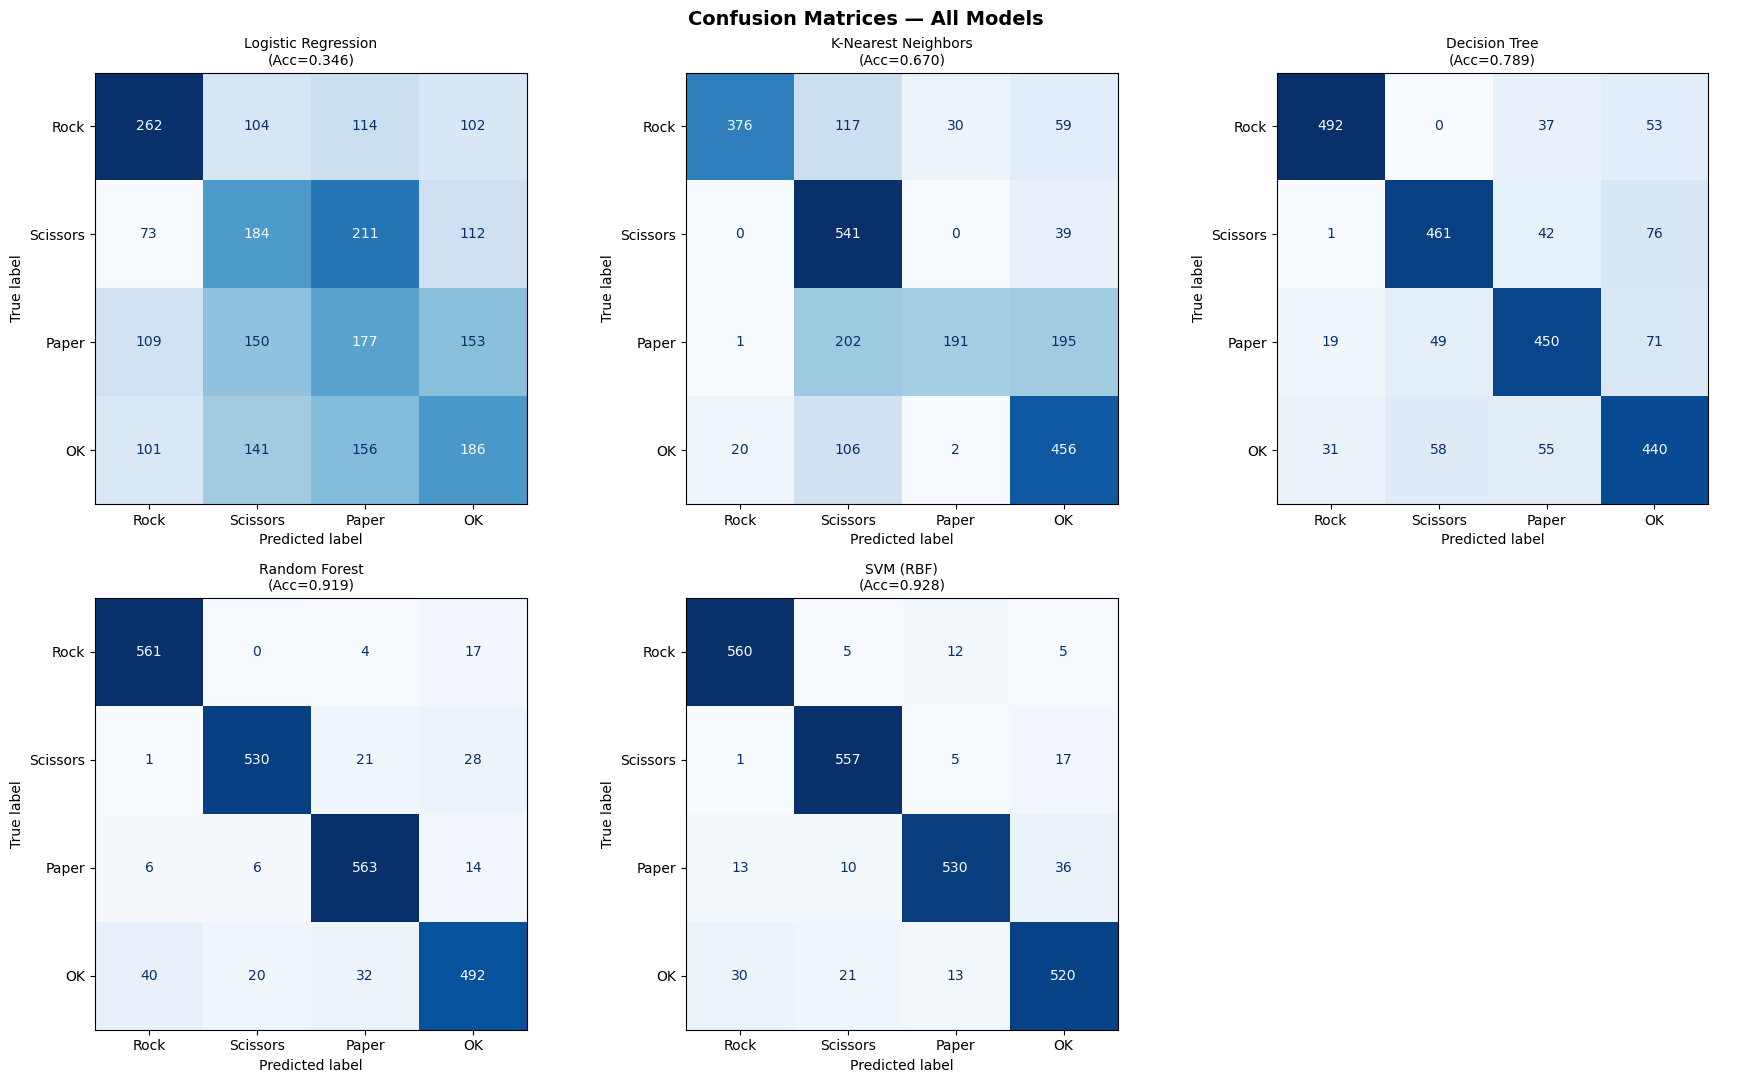


  [Saved] confusion_matrices.png


In [27]:
# 7. CONFUSION MATRICES (all 5 models)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
fig.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight="bold")

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=target_names)
    disp.plot(ax=axes[idx], colorbar=False, cmap="Blues")
    axes[idx].set_title(f"{name}\n(Acc={res['test_acc']:.3f})", fontsize=10)

axes[-1].axis("off")  # hide empty 6th subplot
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n  [Saved] confusion_matrices.png")


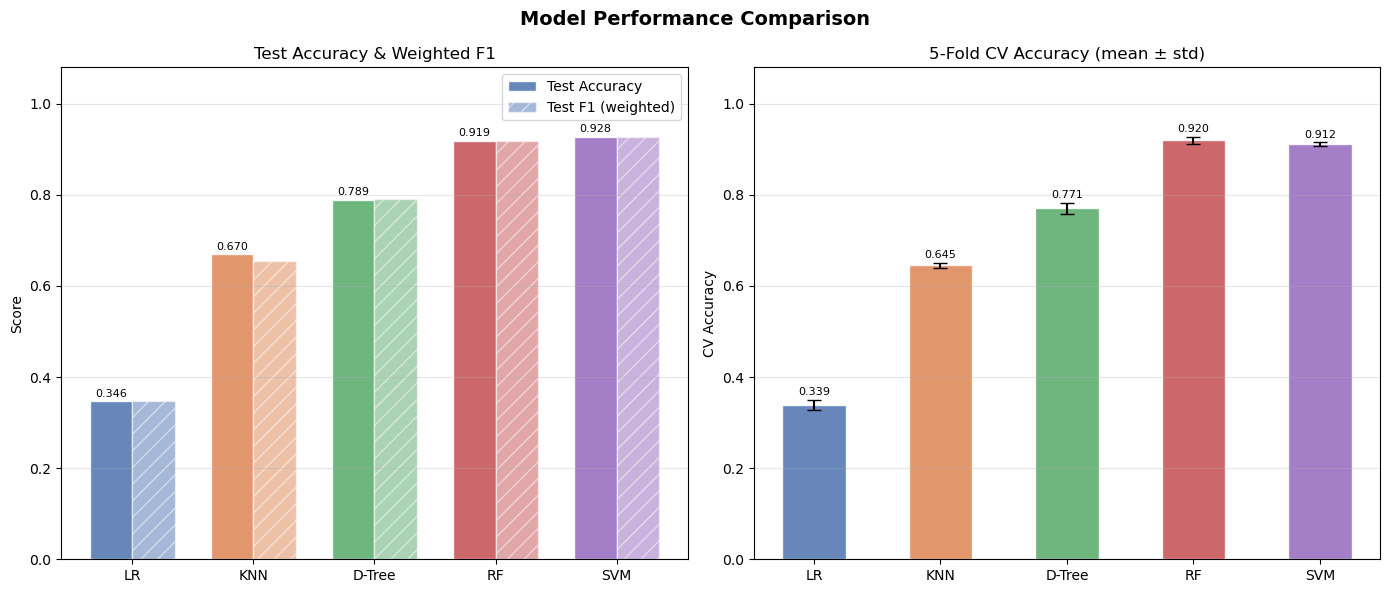

  [Saved] model_comparison.png


In [29]:
# 8. COMPARISON BAR CHART
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Model Performance Comparison", fontsize=14, fontweight="bold")

names = list(results.keys())
test_accs = [results[n]["test_acc"] for n in names]
test_f1s  = [results[n]["test_f1"]  for n in names]
cv_means  = [results[n]["cv_mean"]  for n in names]
cv_stds   = [results[n]["cv_std"]   for n in names]

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#9467BD"]
short_names = ["LR", "KNN", "D-Tree", "RF", "SVM"]

x = np.arange(len(names))
width = 0.35

bars1 = axes[0].bar(x - width/2, test_accs, width, label="Test Accuracy",
                    color=colors, alpha=0.85, edgecolor="white")
bars2 = axes[0].bar(x + width/2, test_f1s, width, label="Test F1 (weighted)",
                    color=colors, alpha=0.5, edgecolor="white", hatch="//")
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_names)
axes[0].set_ylim(0, 1.08)
axes[0].set_ylabel("Score")
axes[0].set_title("Test Accuracy & Weighted F1")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

axes[1].bar(x, cv_means, width=0.5, color=colors, alpha=0.85,
            yerr=cv_stds, capsize=5, edgecolor="white")
axes[1].set_xticks(x)
axes[1].set_xticklabels(short_names)
axes[1].set_ylim(0, 1.08)
axes[1].set_ylabel("CV Accuracy")
axes[1].set_title("5-Fold CV Accuracy (mean ± std)")
axes[1].grid(axis="y", alpha=0.3)
for i, (m, s) in enumerate(zip(cv_means, cv_stds)):
    axes[1].text(i, m + s + 0.005, f"{m:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("  [Saved] model_comparison.png")